In [25]:
data_dir = '/home/mjehangir/telomere-sv-analysis/data/'

In [26]:
setwd(data_dir)

In [27]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(scales)

Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

In [57]:
library(readr)
library(dplyr)

# Read your original SV file
sv_data <- read_tsv("savana_all_somatic_SVs.txt")

# Convert into BED-like format
data <- sv_data %>%
  mutate(
    chr = CHROM,
    start = POS,
    end = case_when(
      SVTYPE == "INS" ~ POS + 1,  # insertions: end ~ start+1
      !is.na(SVLEN)   ~ POS + abs(as.numeric(SVLEN)),
      TRUE ~ POS
    ),
    size = case_when(
      SVTYPE == "INS" ~ abs(as.numeric(SVLEN)),  # use SVLEN directly
      !is.na(SVLEN)   ~ abs(as.numeric(SVLEN)),
      TRUE ~ abs(end - start)
    ),
    type = SVTYPE,
    sample = Sample
  ) %>%
  select(chr, start, end, size, type, sample)
head(data)
# Write out
#write_tsv(data, "savana_all_samples_SVs.bed")


Rows: 138105 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): Sample, CHROM, SVTYPE, CLASS, INFO
dbl (2): POS, SVLEN

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


chr,start,end,size,type,sample
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
chr1,1101414,1101581,167,BND,2436A
chr1,1101581,1101748,167,BND,2436A
chr1,1116428,1116460,32,BND,2436A
chr1,1116460,1116492,32,BND,2436A
chr1,1364479,1364512,33,BND,2436A
chr1,1364512,1364545,33,BND,2436A


In [45]:
# Load the data from your txt file
file_path <- "./sniffles_somatic_merged_svs.tsv"
data <- read.table(file_path, header = TRUE, sep = "\t")
head(data)

,chr,start,end,size,type,sample
,<chr>,<int>,<chr>,<int>,<chr>,<chr>
1,chr1,747308,747308,54,INS,2436A
2,chr1,1879917,1880050,133,DEL,2436A
3,chr1,2212401,2213443,1042,DEL,2436A
4,chr1,2266497,2266497,943,INS,2436A
5,chr1,2266544,2270625,4081,DEL,2436A
6,chr1,2349661,2349723,62,DEL,2436A


In [58]:
library(dplyr)

# Step 1: Create a unique SV ID
data <- data %>%
  mutate(SV_id = paste(chr, start, end, type, sep = "_"))

# Step 2: Count how many unique samples each SV appears in
sv_sample_counts <- data %>%
  distinct(SV_id, sample) %>%
  group_by(SV_id) %>%
  summarise(shared_in = n(), .groups = "drop")

# Step 3: Filter SVs shared across all 20 samples
shared_svs <- sv_sample_counts %>%
  filter(shared_in == 20)

# Step 4: Get full details of shared SVs including size
shared_sv_list <- data %>%
  filter(SV_id %in% shared_svs$SV_id) %>%
  distinct(SV_id, chr, start, end, size, type)

# Step 5: Print the result
print(shared_sv_list)


# A tibble: 28 × 6
   SV_id                        chr       start       end  size type 
   <chr>                        <chr>     <dbl>     <dbl> <dbl> <chr>
 1 chr1_6282283_6282590_BND     chr1    6282283   6282590   307 BND  
 2 chr1_6282590_6282897_BND     chr1    6282590   6282897   307 BND  
 3 chr2_27957989_27958327_BND   chr2   27957989  27958327   338 BND  
 4 chr2_27958327_27958665_BND   chr2   27958327  27958665   338 BND  
 5 chr3_174953046_174954048_BND chr3  174953046 174954048  1002 BND  
 6 chr3_174954048_174955050_BND chr3  174954048 174955050  1002 BND  
 7 chr4_69385430_69386935_BND   chr4   69385430  69386935  1505 BND  
 8 chr4_69386935_69388440_BND   chr4   69386935  69388440  1505 BND  
 9 chr5_125328627_125328954_BND chr5  125328627 125328954   327 BND  
10 chr5_125328954_125329281_BND chr5  125328954 125329281   327 BND  
# ℹ 18 more rows


In [59]:

data <- data %>%
  dplyr::rename(filename = sample)
head(data)

chr,start,end,size,type,filename,SV_id
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
chr1,1101414,1101581,167,BND,2436A,chr1_1101414_1101581_BND
chr1,1101581,1101748,167,BND,2436A,chr1_1101581_1101748_BND
chr1,1116428,1116460,32,BND,2436A,chr1_1116428_1116460_BND
chr1,1116460,1116492,32,BND,2436A,chr1_1116460_1116492_BND
chr1,1364479,1364512,33,BND,2436A,chr1_1364479_1364512_BND
chr1,1364512,1364545,33,BND,2436A,chr1_1364512_1364545_BND


In [60]:
data <- data %>%
  #mutate(size = abs(as.numeric(end) - as.numeric(start))) %>%  # Recalculate size in base pairs
  filter(size > 50)  # Only keep rows where the size is greater than 0

# Show the first few rows of the data
head(data)



chr,start,end,size,type,filename,SV_id
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
chr1,1101414,1101581,167,BND,2436A,chr1_1101414_1101581_BND
chr1,1101581,1101748,167,BND,2436A,chr1_1101581_1101748_BND
chr1,2349188,2349724,536,BND,2436A,chr1_2349188_2349724_BND
chr1,2349724,2350260,536,BND,2436A,chr1_2349724_2350260_BND
chr1,3606393,3606722,329,BND,2436A,chr1_3606393_3606722_BND
chr1,3606722,3607051,329,BND,2436A,chr1_3606722_3607051_BND


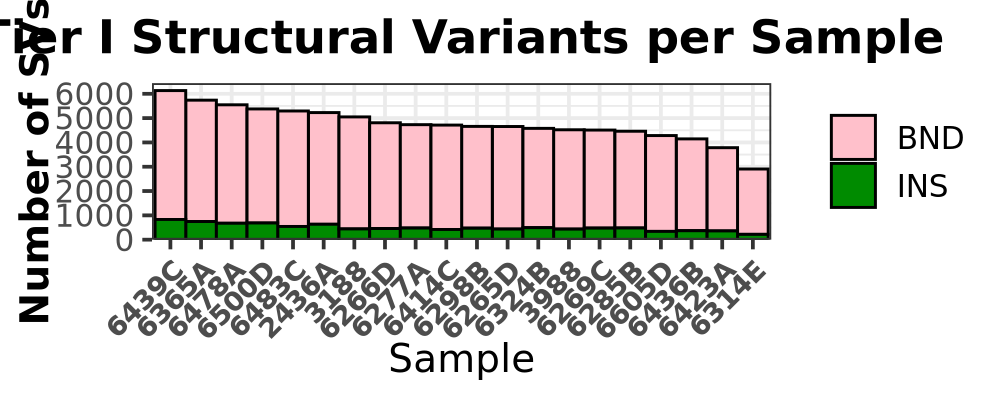

In [61]:
library(ggplot2)
library(dplyr)
library(forcats)
library(scales)


# Custom colors
sv_colors <- c("DEL" = "skyblue3",
               "DUP" = "orangered",
               "BND" = "pink",
               "INV" = "orange",
              "INS" = "green4")

#–––––––––––––––––––––––––––––––––––––
# p1: SV counts per sample (sorted & stacked)
#–––––––––––––––––––––––––––––––––––––
# Order samples by total SV counts
sample_order <- data %>%
  count(filename) %>%
  arrange(desc(n)) %>%
  pull(filename)

p1 <- data %>%
  count(filename, type) %>%
  mutate(filename = factor(filename, levels = sample_order)) %>%
  ggplot(aes(x = filename, y = n, fill = type)) +
  geom_bar(stat = "identity", position = "stack", color = "black", width = 1) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05)), 
                     breaks = pretty_breaks(n = 6)) +
  scale_fill_manual(values = sv_colors) +
  labs(x = "Sample", y = "Number of SVs",
       title = "Tier I Structural Variants per Sample") +
  theme_bw(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold", size = 10),
    axis.title.y = element_text(face = "bold"),
    plot.title  = element_text(face = "bold", hjust = 0.5),
    legend.title = element_blank()
  )

#–––––––––––––––––––––––––––––––––––––
# p2: Size distribution separate for each type
#–––––––––––––––––––––––––––––––––––––
# Define size bins
#data_bins <- data_noINS %>%
 # mutate(size_bin = cut(size,
  #                      breaks = c(0, 1e3, 1e4, 1e5, 1e6, Inf),
   #                     labels = c("<1 kb", "1–10 kb", "10–100 kb", "100 kb–1 Mb", ">1 Mb"),
    #                    right = FALSE))


data_bins <- data %>%
  mutate(
    size_bin = cut(
      size,
      breaks = c(0, 1e2, 5e2, 1e3, 5e3, 1e4, 1e5, 1e6, 1e7, Inf),
      labels = c("<0.1 kb", "0.1–0.5 kb", "0.5–1 kb", "1–5 kb", "5–10 kb",
                 "10–100 kb", "0.1–1 Mb", "1–10 Mb", ">10 Mb"),
      right = FALSE,
      include.lowest = TRUE
    )
  )
p1

In [62]:
head(data_bins)

chr,start,end,size,type,filename,SV_id,size_bin
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<fct>
chr1,1101414,1101581,167,BND,2436A,chr1_1101414_1101581_BND,0.1–0.5 kb
chr1,1101581,1101748,167,BND,2436A,chr1_1101581_1101748_BND,0.1–0.5 kb
chr1,2349188,2349724,536,BND,2436A,chr1_2349188_2349724_BND,0.5–1 kb
chr1,2349724,2350260,536,BND,2436A,chr1_2349724_2350260_BND,0.5–1 kb
chr1,3606393,3606722,329,BND,2436A,chr1_3606393_3606722_BND,0.1–0.5 kb
chr1,3606722,3607051,329,BND,2436A,chr1_3606722_3607051_BND,0.1–0.5 kb


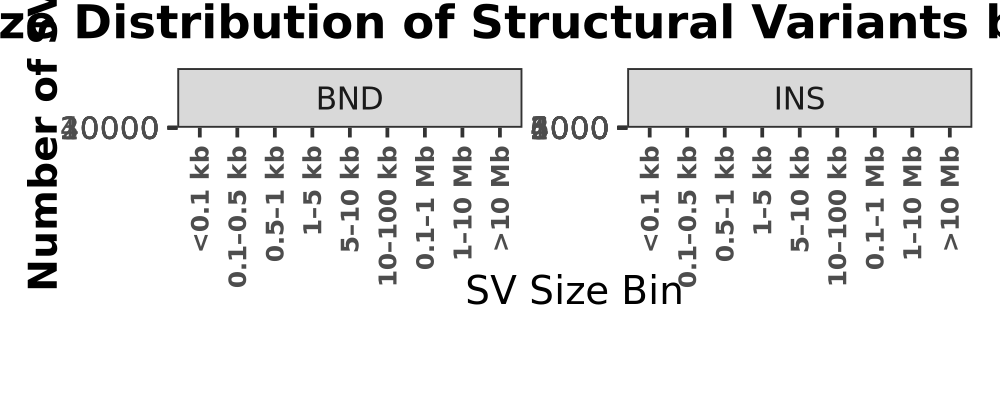

In [63]:
p2 <- data_bins %>%
  count(size_bin, type) %>%
  ggplot(aes(x = size_bin, y = n, fill = type)) +
  geom_bar(stat = "identity", color = "black", width = 0.7) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05)),
                     breaks = scales::pretty_breaks(n = 6)) +
  scale_fill_manual(values = sv_colors) +
  facet_wrap(~ type, scales = "free_y", nrow = 1) +  # <- one row
  labs(x = "SV Size Bin", y = "Number of SVs",
       title = "Size Distribution of Structural Variants by Class") +
  theme_bw(base_size = 14) +
  theme(
    axis.text.x  = element_text(angle = 90, vjust = 0.5, hjust = 1, face = "bold", size = 9),
    axis.title.y = element_text(face = "bold"),
    plot.title   = element_text(face = "bold", hjust = 0.5),
    legend.position = "none",
    plot.margin = margin(t = 10, r = 10, b = 40, l = 10)
  )
p2

In [64]:
# Output directory
#outdir <- "/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/"
#dir.create(outdir, showWarnings = FALSE, recursive = TRUE)
#ggsave(file.path(outdir, "total_SV_count_v2.pdf"), plot = p1, width = 7, height = 5, dpi = 200)
#ggsave(file.path(outdir, "size_distribution_v2.pdf"), plot = p2, width = 12, height = 4, dpi = 200)


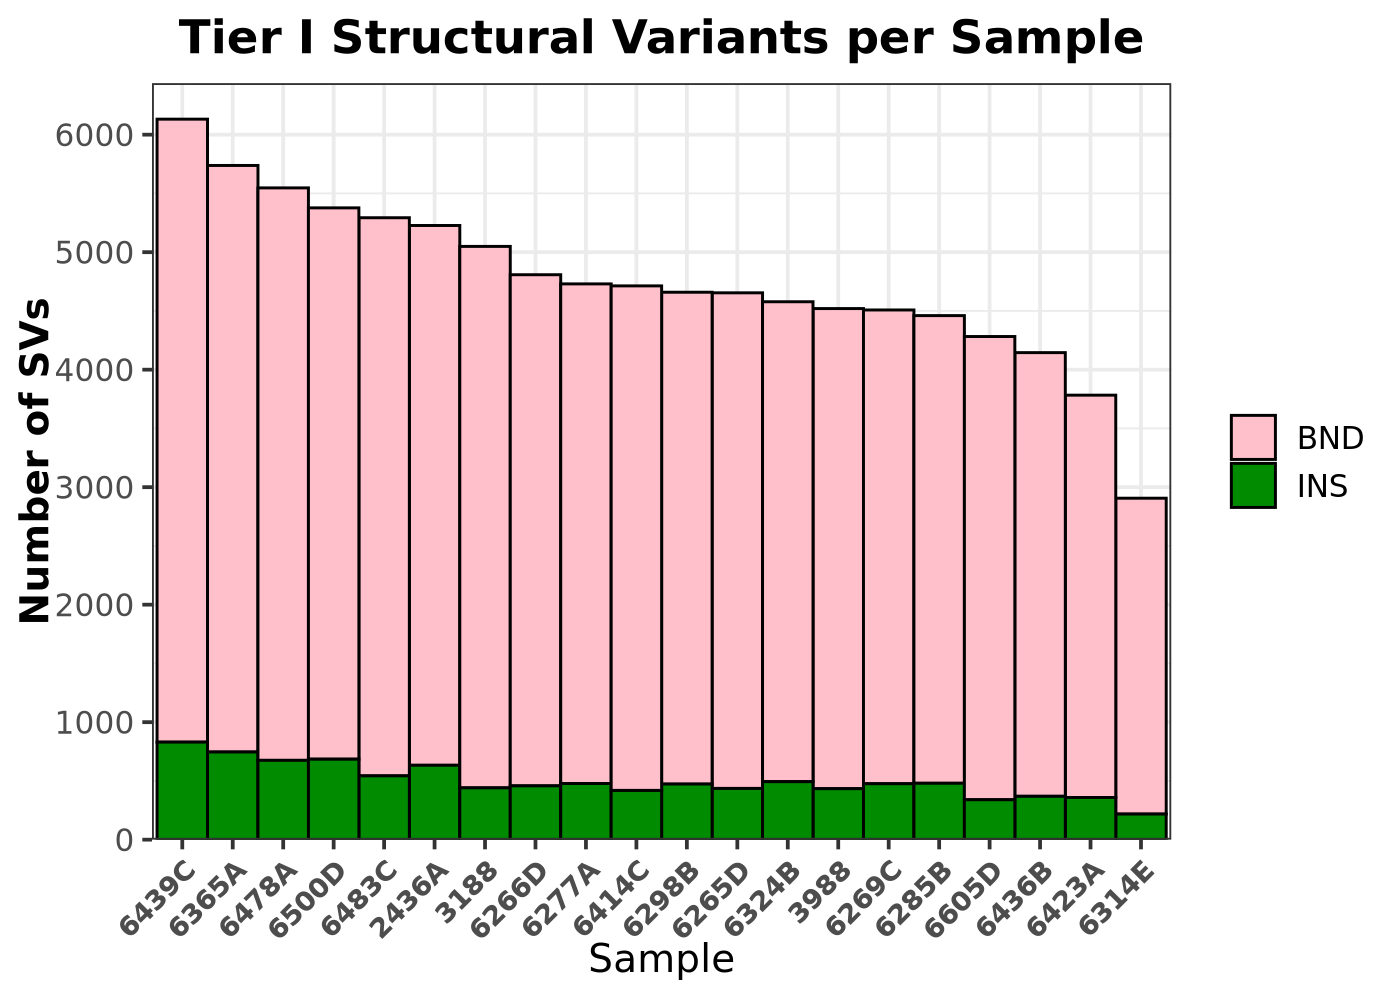

In [65]:
options(repr.plot.width = 7, repr.plot.height = 5, repr.plot.res = 200)

# Show plots
print(p1)

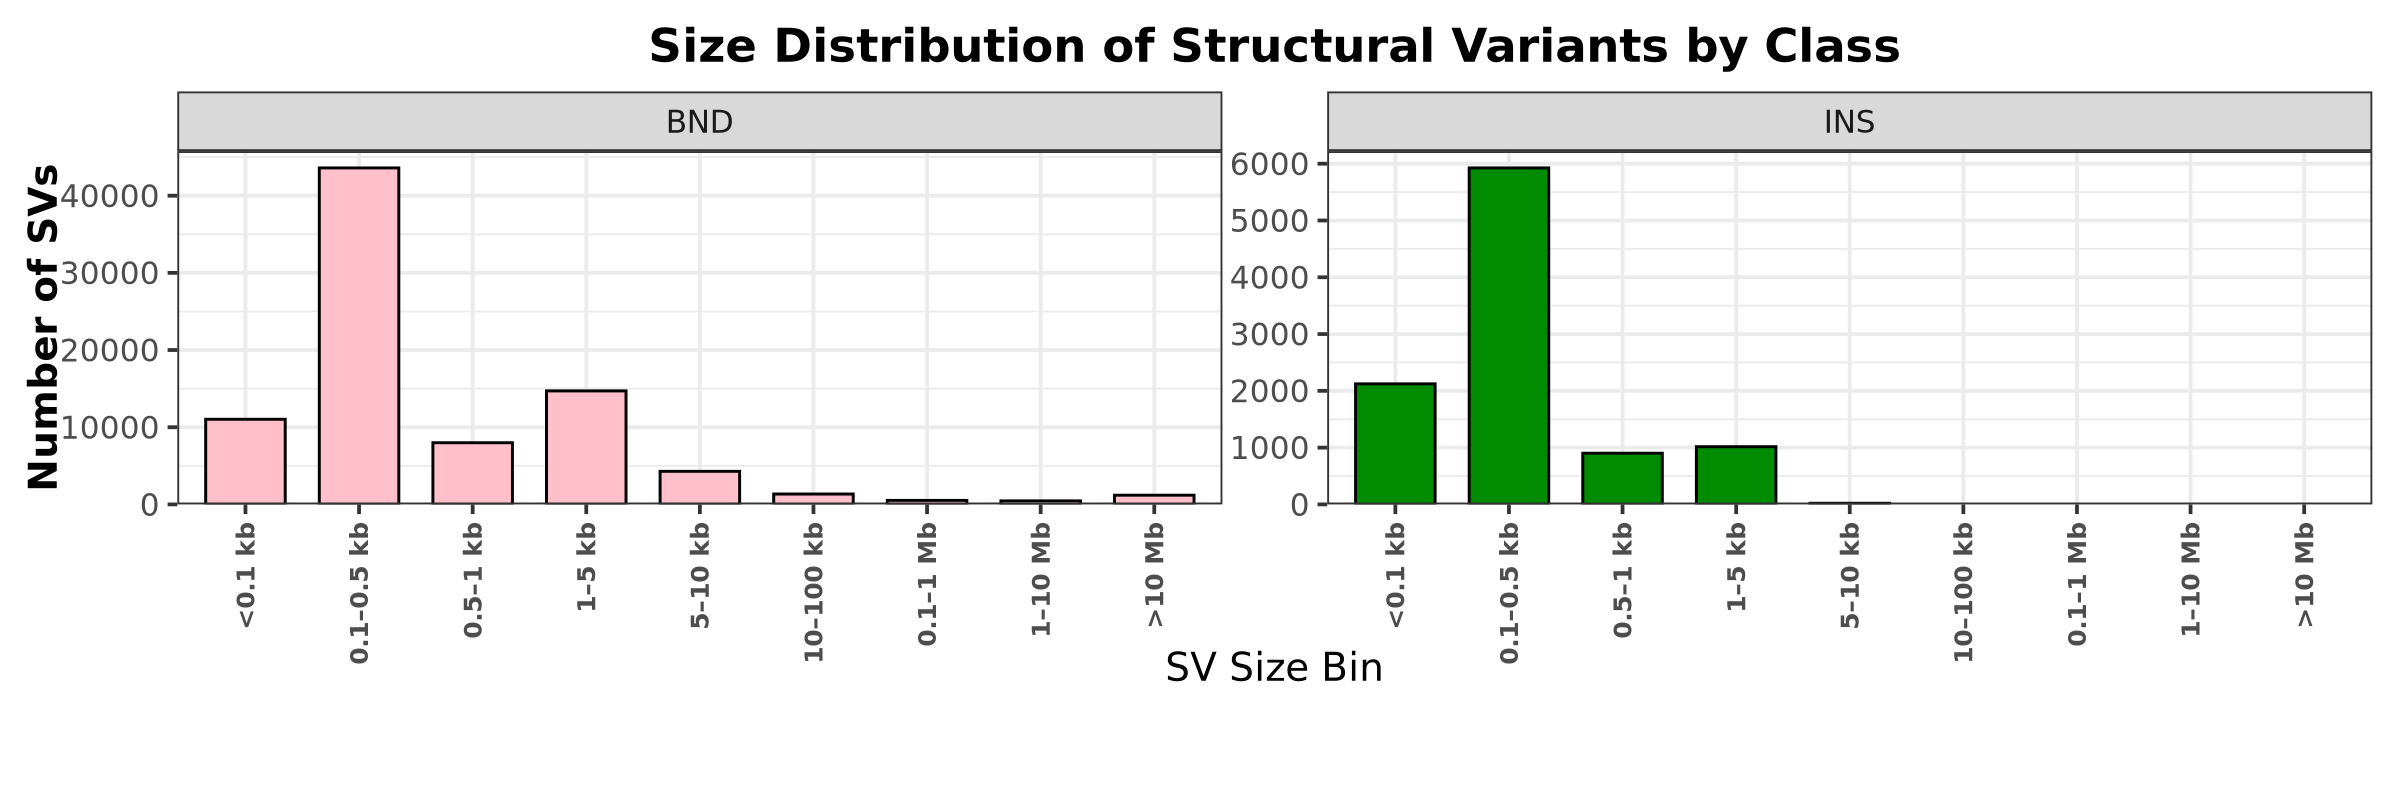

In [66]:
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 200)

print(p2)

`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


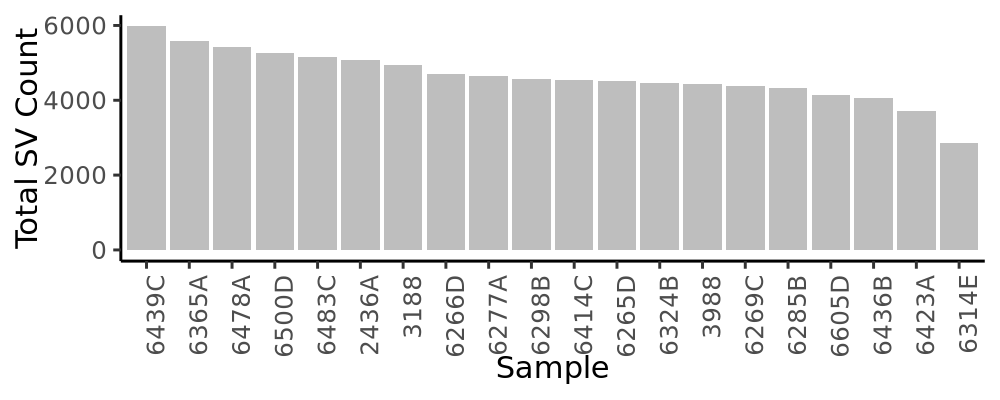

`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


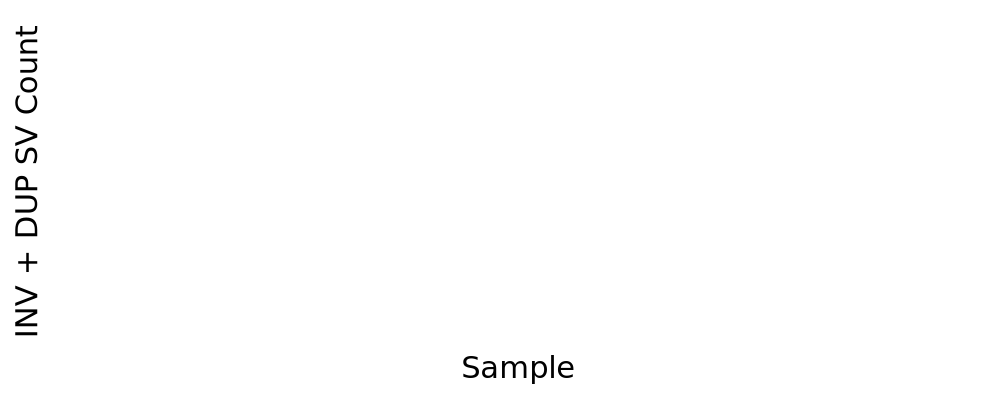

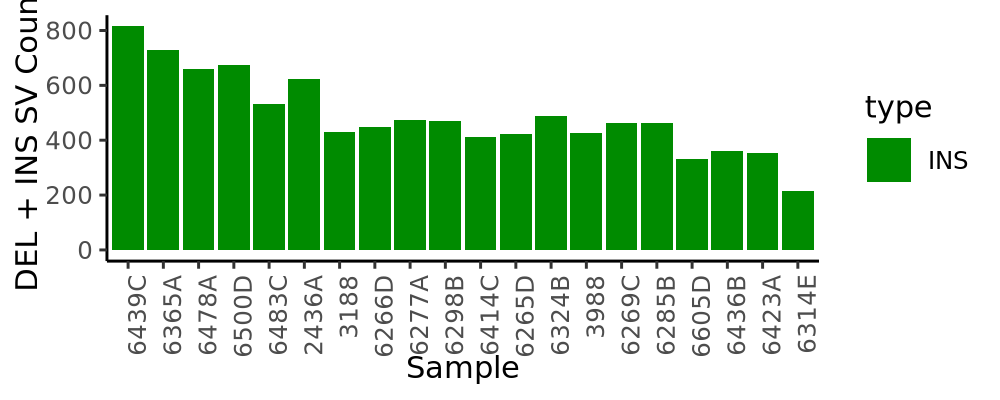

In [67]:

# Step 1: Filter the data to keep only chromosomes from chr1 to chr22
data <- data %>%
  filter(chr %in% paste0("chr", 1:22))  # Filter out chrX, chrY, chrM

# Step 2: Total SVs per sample bar plot (raw count, ordered descending)
total_SVs <- data %>%
  group_by(filename) %>%
  summarize(Total_SV = n())  # Count number of SVs per sample

# Sort samples by total SV count (descending order)
sorted_samples <- total_SVs %>%
  arrange(desc(Total_SV)) %>%
  pull(filename)

options(repr.plot.width = 5, repr.plot.height = 2, repr.plot.res = 200)

# Barplot for total SV count per sample (ordered descending)
ggplot(total_SVs, aes(x = factor(filename, levels = sorted_samples), y = Total_SV)) +
  geom_bar(stat = "identity", fill = "grey") +
  labs(x = "Sample", y = "Total SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity


# Step 3: Stacked bar plot by SV types (combining INV + DUP and DEL + INS into separate plots)
# INV + DUP combined Plot
sv_types_INV_DUP <- data %>%
  filter(type %in% c("INV", "DUP")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of INV and DUP SVs per sample

ggplot(sv_types_INV_DUP, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("INV" = "orange", "DUP" = "orangered")) +
  labs(x = "Sample", y = "INV + DUP SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity


# DEL + INS combined Plot
sv_types_DEL_INS <- data %>%
  filter(type %in% c("DEL", "INS")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of DEL and INS SVs per sample

ggplot(sv_types_DEL_INS, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("DEL" = "skyblue3", "INS" = "green4")) +
  labs(x = "Sample", y = "DEL + INS SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


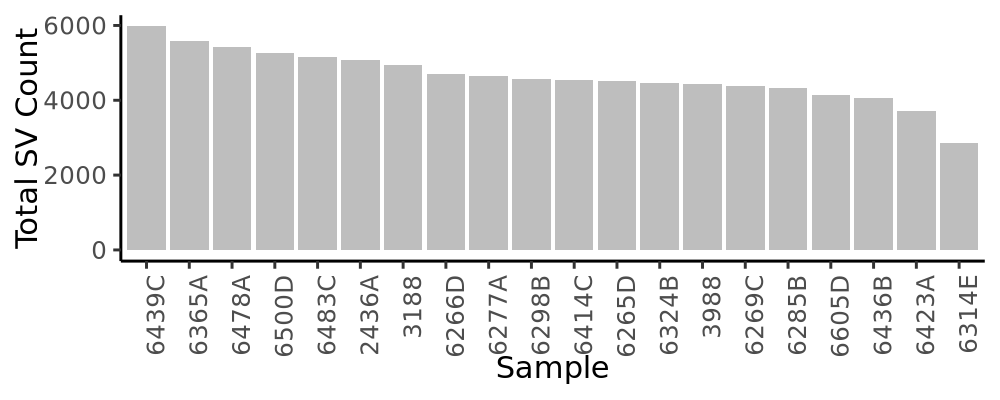

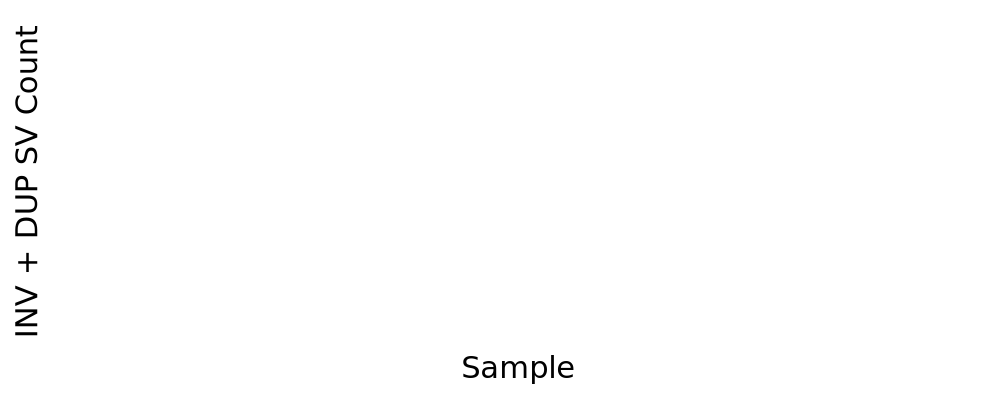

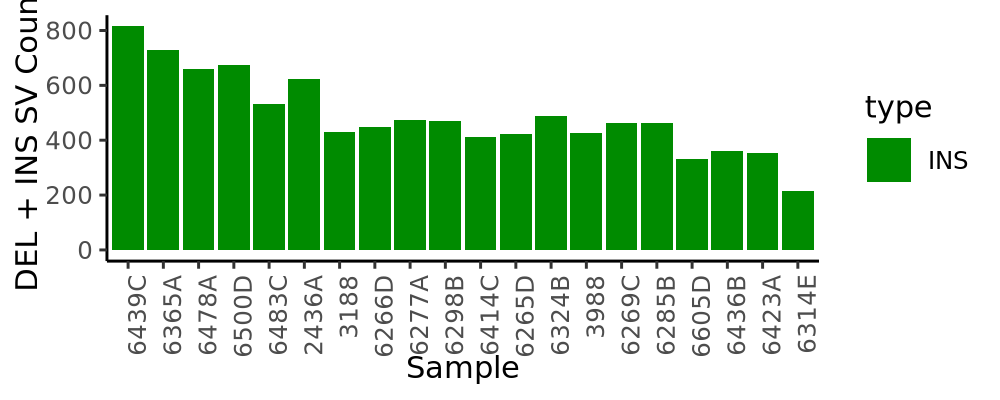

In [68]:
library(ggplot2)
library(dplyr)

# Output directory
outdir <- "/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/"
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)

# -----------------------------
# 1. Total SV count barplot
p1 <- ggplot(total_SVs, aes(x = factor(filename, levels = sorted_samples), y = Total_SV)) +
  geom_bar(stat = "identity", fill = "grey") +
  labs(x = "Sample", y = "Total SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

ggsave(file.path(outdir, "total_SV_count.pdf"), plot = p1, width = 5, height = 2.5, dpi = 200)


# -----------------------------
# 2. INV + DUP combined
sv_types_INV_DUP <- data %>%
  filter(type %in% c("INV", "DUP")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n(), .groups = "drop")

p2 <- ggplot(sv_types_INV_DUP, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("INV" = "orange", "DUP" = "orangered")) +
  labs(x = "Sample", y = "INV + DUP SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

#ggsave(file.path(outdir, "INV_DUP_SV_count.pdf"), plot = p2, width = 5, height = 2.5, dpi = 200)


# -----------------------------
# 3. DEL + INS combined
sv_types_DEL_INS <- data %>%
  filter(type %in% c("DEL", "INS")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n(), .groups = "drop")

p3 <- ggplot(sv_types_DEL_INS, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("DEL" = "skyblue3", "INS" = "green4")) +
  labs(x = "Sample", y = "DEL + INS SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

#ggsave(file.path(outdir, "DEL_INS_SV_count.pdf"), plot = p3, width = 5, height = 2.5, dpi = 200)
p1
p2
p3

In [100]:
head(total_SVs)

filename,Total_SV
<chr>,<int>
2436A,333
3188,876
3988,369
6265D,586
6266D,411
6269C,368


In [101]:
total_svs_sorted <- total_SVs %>%
  arrange(desc(Total_SV))

print(total_svs_sorted)

# A tibble: 20 × 2
   filename Total_SV
   <chr>       <int>
 1 3188          876
 2 6439C         711
 3 6365A         636
 4 6265D         586
 5 6277A         577
 6 6414C         462
 7 6483C         445
 8 6266D         411
 9 3988          369
10 6269C         368
11 6324B         347
12 6285B         342
13 6436B         340
14 6478A         335
15 2436A         333
16 6605D         330
17 6298B         318
18 6500D         295
19 6423A         292
20 6314E         257


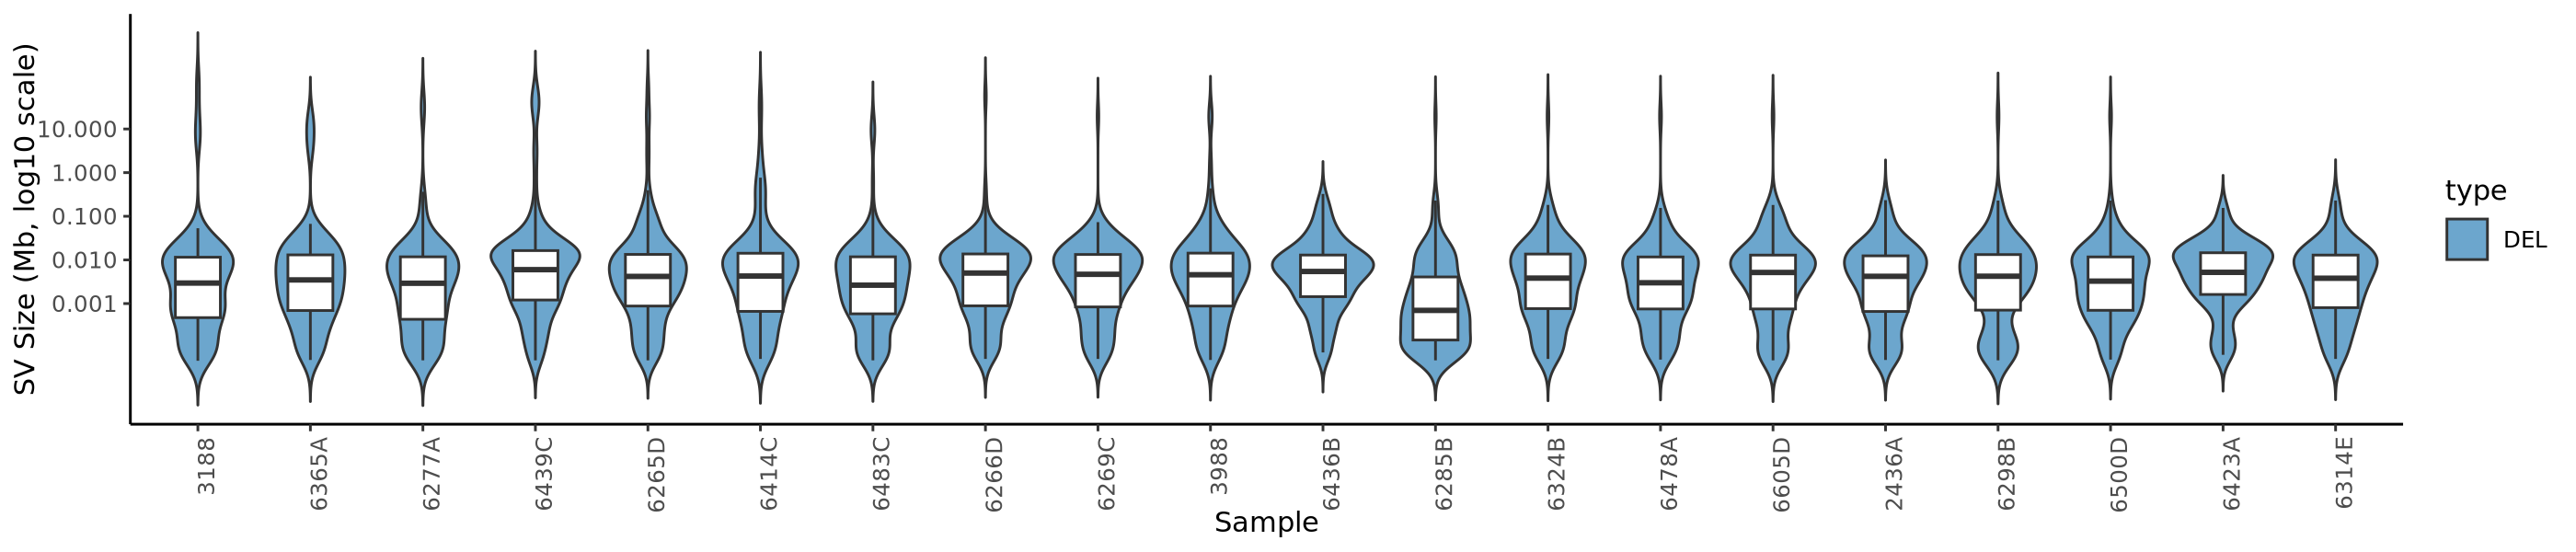

In [86]:

options(repr.plot.width = 14, repr.plot.height = 3, repr.plot.res = 200)

del_violin_plot<-ggplot(data %>% filter(type == "DEL"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.01, 0.1, 1, 10), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("DEL" = "skyblue3")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
print(del_violin_plot)
# Save the plot to the specified directory
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/DEL_SV_Size_violin_v2.pdf", plot = del_violin_plot, height = 6, width = 14)


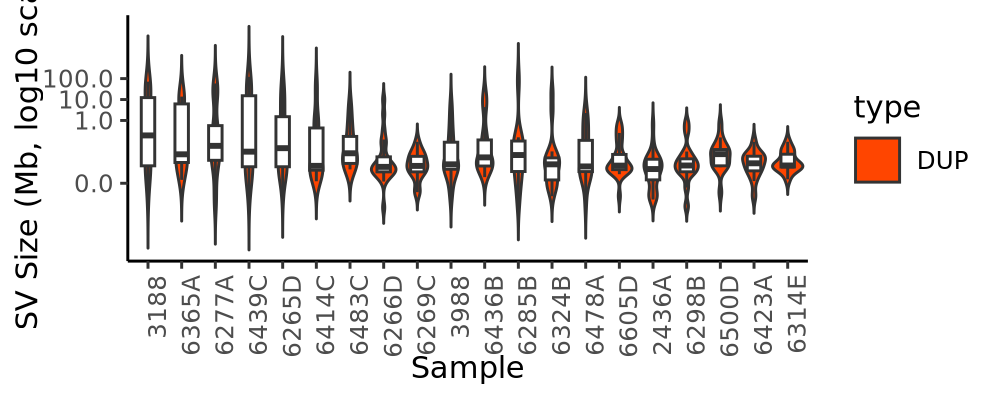

In [12]:
dup_violin_plot<-ggplot(data %>% filter(type == "DUP"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 1, 10, 100), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("DUP" = "orangered")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/DUP_SV_Size_violin_v2.pdf", plot = dup_violin_plot, height = 6, width = 14)
dup_violin_plot

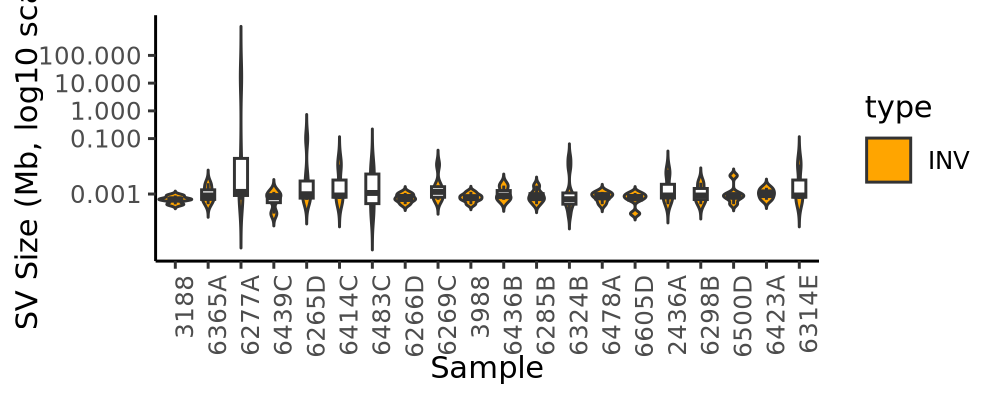

In [13]:
inv_violin_plot<-ggplot(data %>% filter(type == "INV"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE, width = 1) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.1, 1, 10, 100), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("INV" = "orange")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/INV_SV_Size_violin_v2.pdf", plot = inv_violin_plot, height = 6, width = 14)
inv_violin_plot

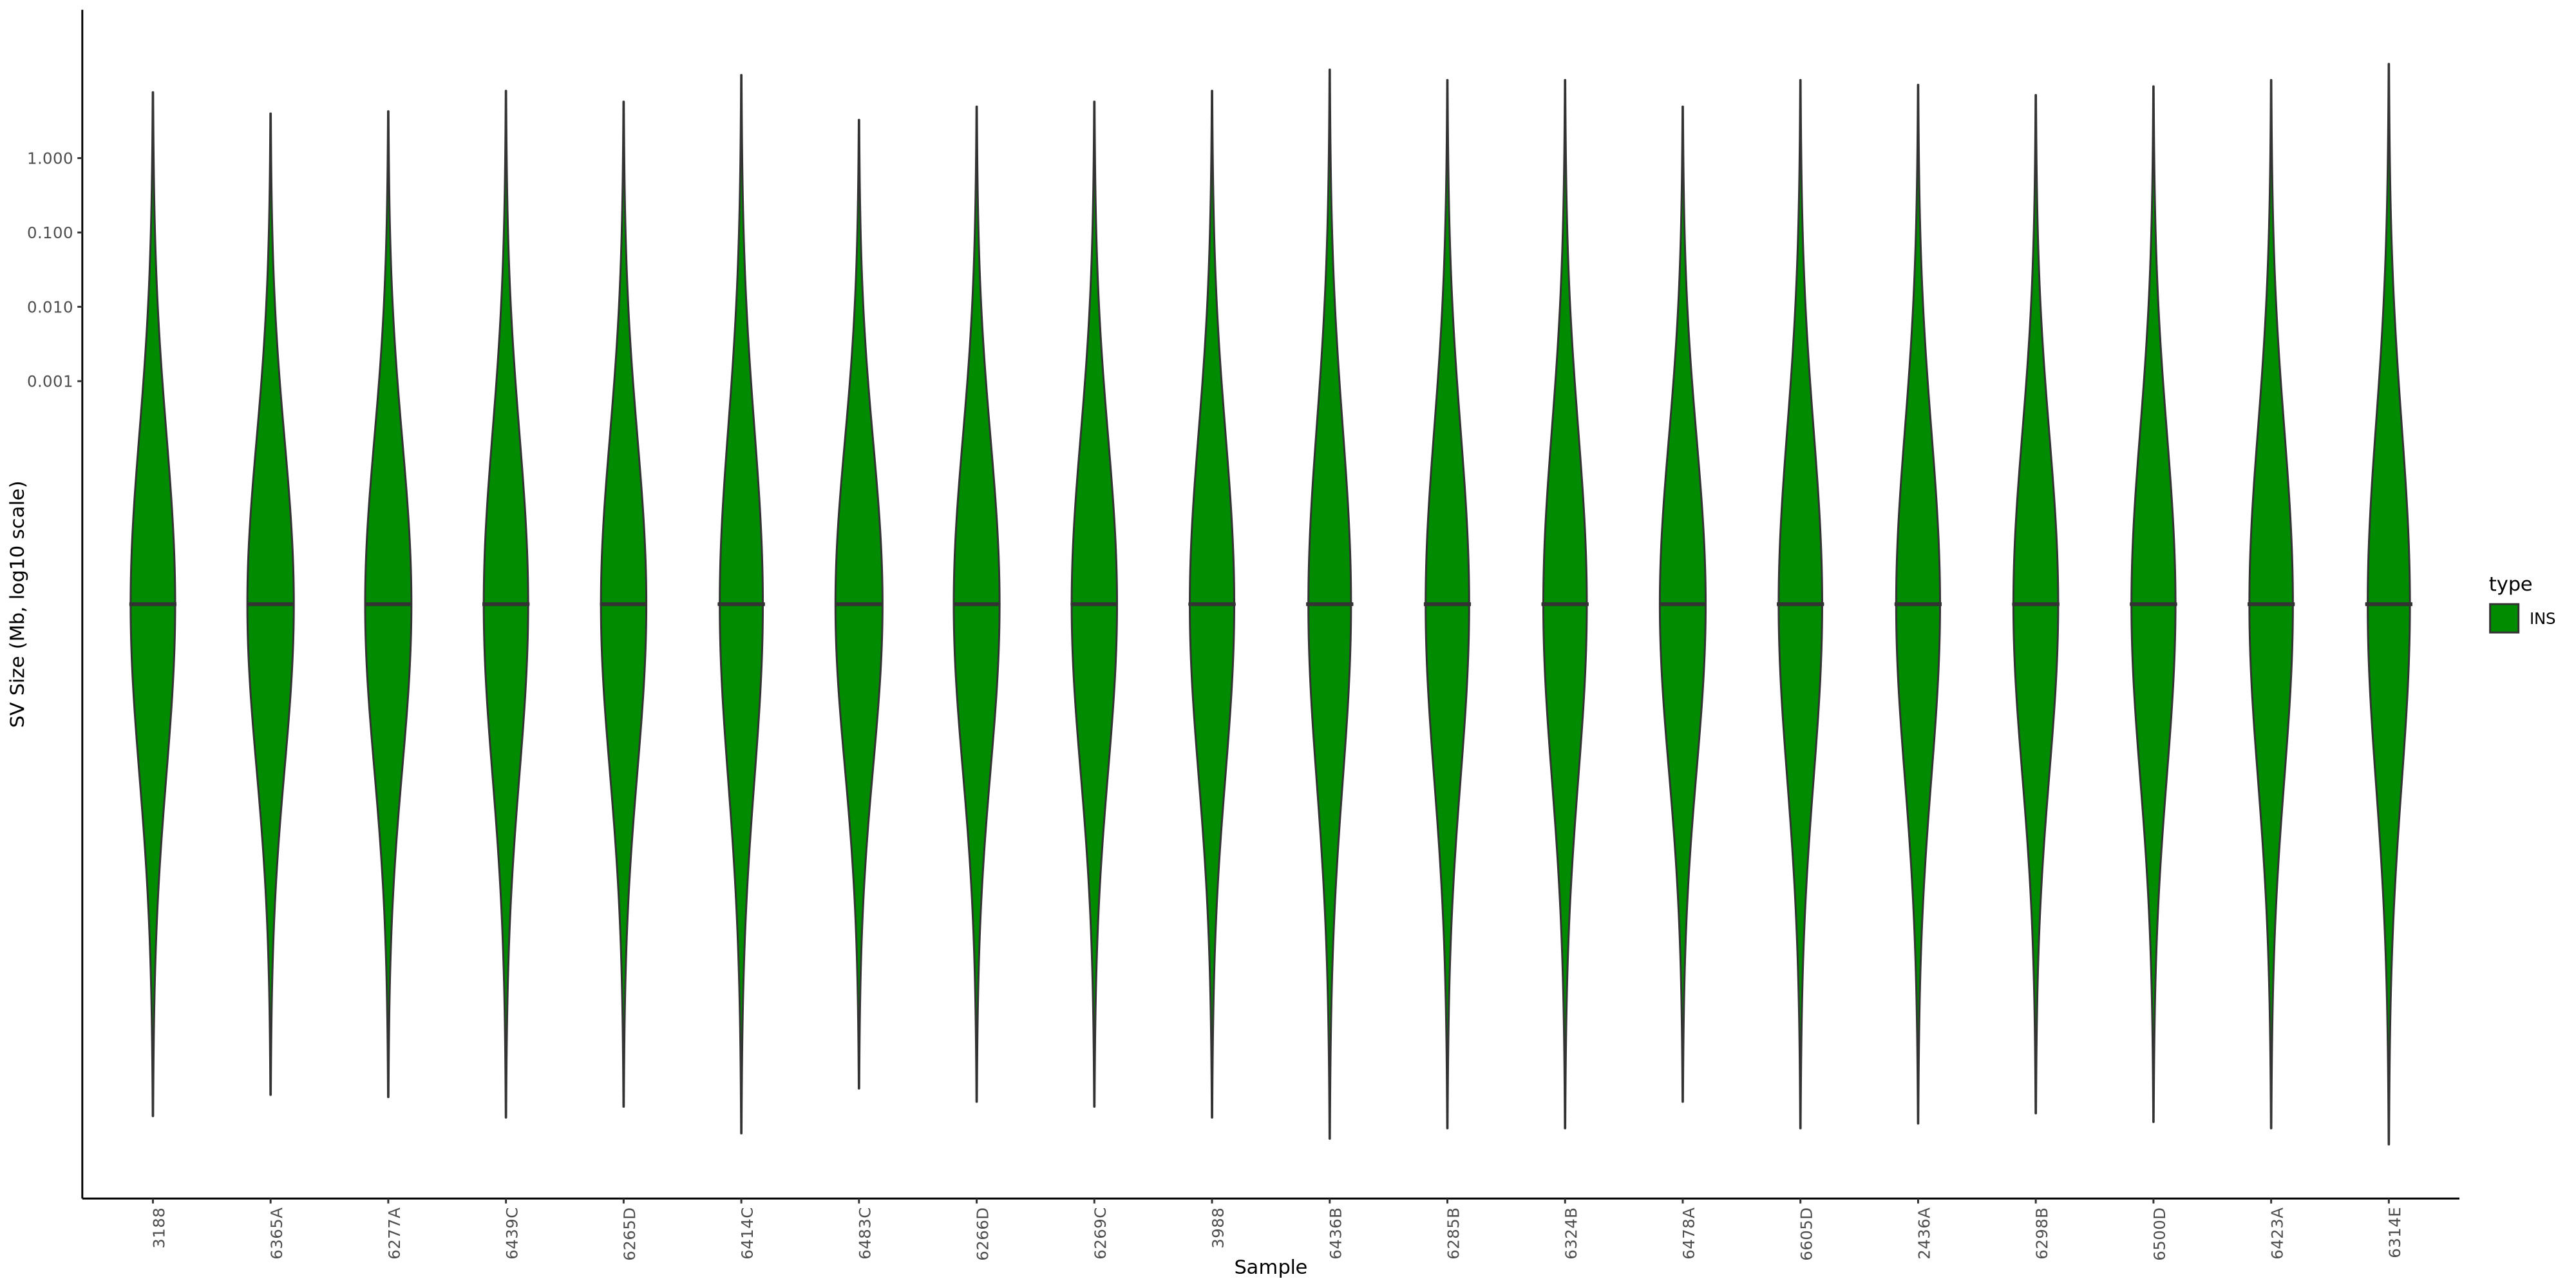

In [62]:
ins_violin_plot<-ggplot(data %>% filter(type == "INS"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE, width = 0.4) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.01, 0.1, 1), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("INS" = "green4")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/INS_SV_Size_violin_v2.pdf", plot = ins_violin_plot, height = 6, width = 14)
ins_violin_plot

In [23]:
# Filter out BND SVs
data_filtered <- data %>% filter(type != "BND")

# Ensure correct column name for SV length
# If 'SV_length' does not exist, replace with the actual column name (e.g., 'size')
sv_summary <- data_filtered %>%
  group_by(filename, type) %>%
  summarize(SV_length = sum(size), .groups = "drop")  # Change 'size' if needed

# Convert SV length to log10 scale
sv_summary <- sv_summary %>%
  mutate(SV_length_log10 = log10(SV_length))

In [24]:
head(data_filtered)

,chr,start,end,size,type,filename,SV_id
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>
1,chr1,1414067,1415349,1282,DEL,2436A,chr1_1414067_1415349_DEL
2,chr1,3010201,3010202,1,INS,2436A,chr1_3010201_3010202_INS
3,chr1,12524812,12554643,29831,DEL,2436A,chr1_12524812_12554643_DEL
4,chr1,16152446,16152447,1,INS,2436A,chr1_16152446_16152447_INS
5,chr1,34498454,34509010,10556,DEL,2436A,chr1_34498454_34509010_DEL
6,chr1,35019427,35019801,374,DUP,2436A,chr1_35019427_35019801_DUP


In [25]:
nrow(data_filtered)

[1] 4698


	Friedman rank sum test

data:  count and type and filename
Friedman chi-squared = 60, df = 3, p-value = 5.878e-13



Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”


  Comparison P_Value_Adjusted
1 DEL vs DUP     0.0005701305
2 DEL vs INS     0.0005725398
3 DEL vs INV     0.0005717359
4 DUP vs INS     0.0005709327
5 DUP vs INV     0.0005637430
6 INS vs INV     0.0005701305


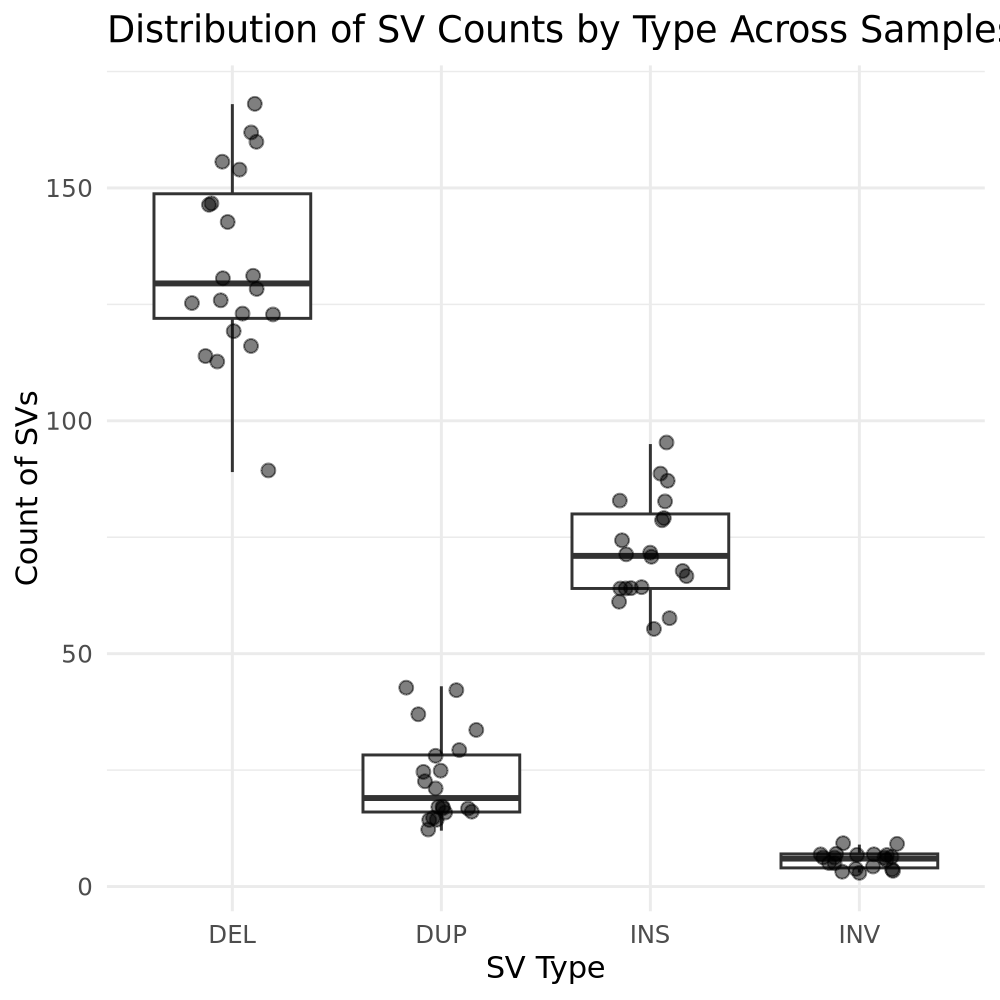

In [39]:
# Load libraries
library(dplyr)
library(tidyr)
library(ggplot2)

# Step 1: Aggregate counts
sv_counts <- data_filtered %>%
  group_by(filename, type) %>%
  summarise(count = n(), .groups = "drop")

# Step 2: Include zeros for missing combinations
sv_counts_complete <- sv_counts %>%
  complete(filename, type, fill = list(count = 0))

# Step 3: Create boxplot
ggplot(sv_counts_complete, aes(x = type, y = count)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.5, size = 2) +
  labs(x = "SV Type", y = "Count of SVs", 
       title = "Distribution of SV Counts by Type Across Samples") +
  theme_minimal()

# Step 4: Statistical tests
# Friedman test
friedman_result <- friedman.test(count ~ type | filename, data = sv_counts_complete)
print(friedman_result)

# If Friedman test is significant, proceed with pairwise comparisons
if (friedman_result$p.value < 0.05) {
  sv_counts_wide <- sv_counts_complete %>%
    pivot_wider(names_from = type, values_from = count)
  types <- colnames(sv_counts_wide)[-1]
  pairs <- combn(types, 2, simplify = FALSE)
  p_values <- sapply(pairs, function(pair) {
    wilcox.test(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], paired = TRUE)$p.value
  })
  p_adjusted <- p.adjust(p_values, method = "bonferroni")
  results <- data.frame(
    Comparison = sapply(pairs, function(p) paste(p[1], "vs", p[2])),
    P_Value_Adjusted = p_adjusted
  )
  print(results)
}

Warning message in wilcox.test.default(c(123, 156, 131, 154, 146, 147, 160, 162, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(123, 156, 131, 154, 146, 147, 160, 162, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(123, 156, 131, 154, 146, 147, 160, 162, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(28, 42, 17, 43, 25, 17, 21, 12, 16, 14, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(123, 156, 131, 154, 146, 147, 160, 162, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(123, 156, 131, 154, 146, 147, 160, 162, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(123, 156, 131, 154, 146, 147, 160, 162, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(28, 42, 17, 43, 25, 17, 21, 12, 16, 14, :
“cannot compute exact p-value with ties”


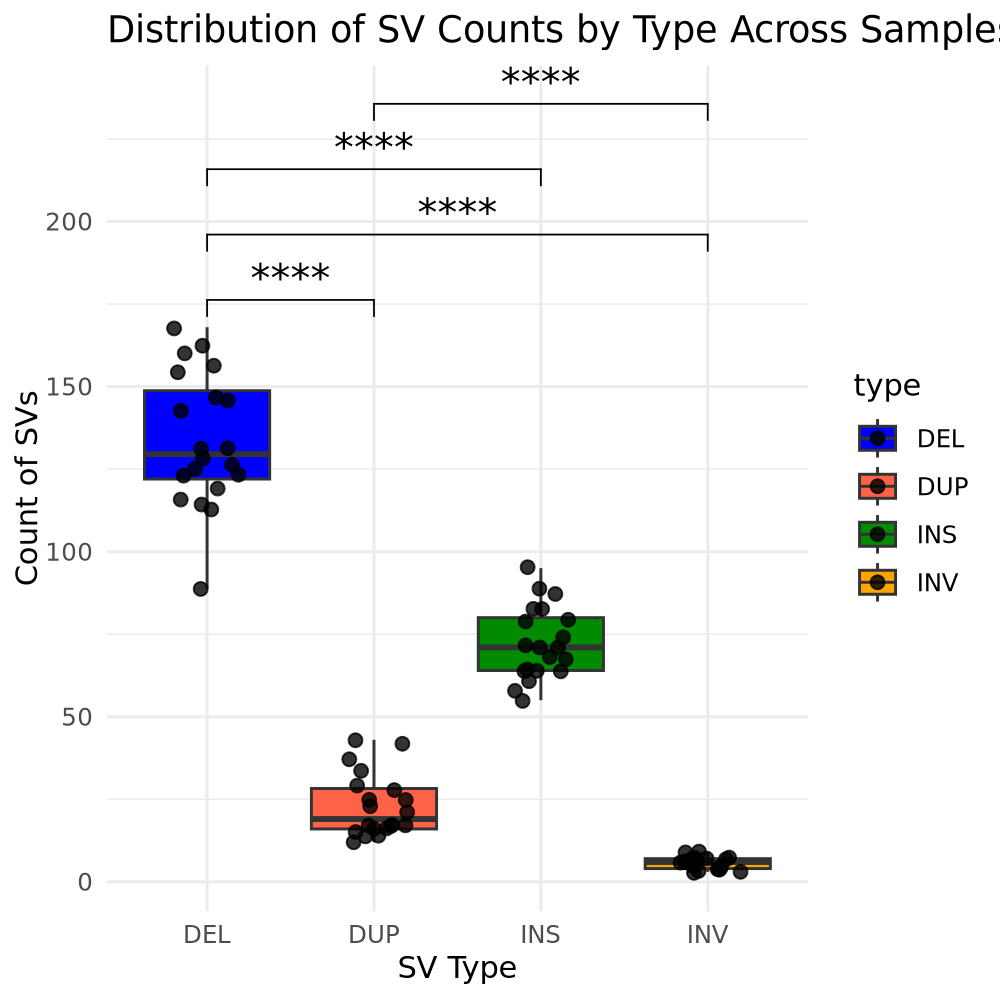

In [45]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

# Define specific colors for each SV type
colors <- c("DEL" = "blue", "DUP" = "tomato", "INV" = "orange", "INS" = "green4")

# Install and load ggpubr if you haven't already
# install.packages("ggpubr")
library(ggpubr)

# Define pairwise comparisons (all six pairs for four groups)
comparisons <- list(
  c("DEL", "DUP"), 
  c("DEL", "INV"), 
  c("DEL", "INS"),
  c("DUP", "INV") 
  #c("DUP", "INS"), 
  #c("INV", "INS")
)

p <- ggplot(sv_counts_complete, aes(x = type, y = count, fill = type)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.8, size = 2) +
  stat_compare_means(comparisons = comparisons, method = "wilcox.test",
                     label = "p.signif", size = 5, exact = FALSE) +
  labs(x = "SV Type", y = "Count of SVs", 
       title = "Distribution of SV Counts by Type Across Samples") +
  scale_fill_manual(values = colors) +
  theme_minimal()

ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/Distribution_sv_types.pdf",
       plot = p, height = 8, width = 10, dpi = 300)
p

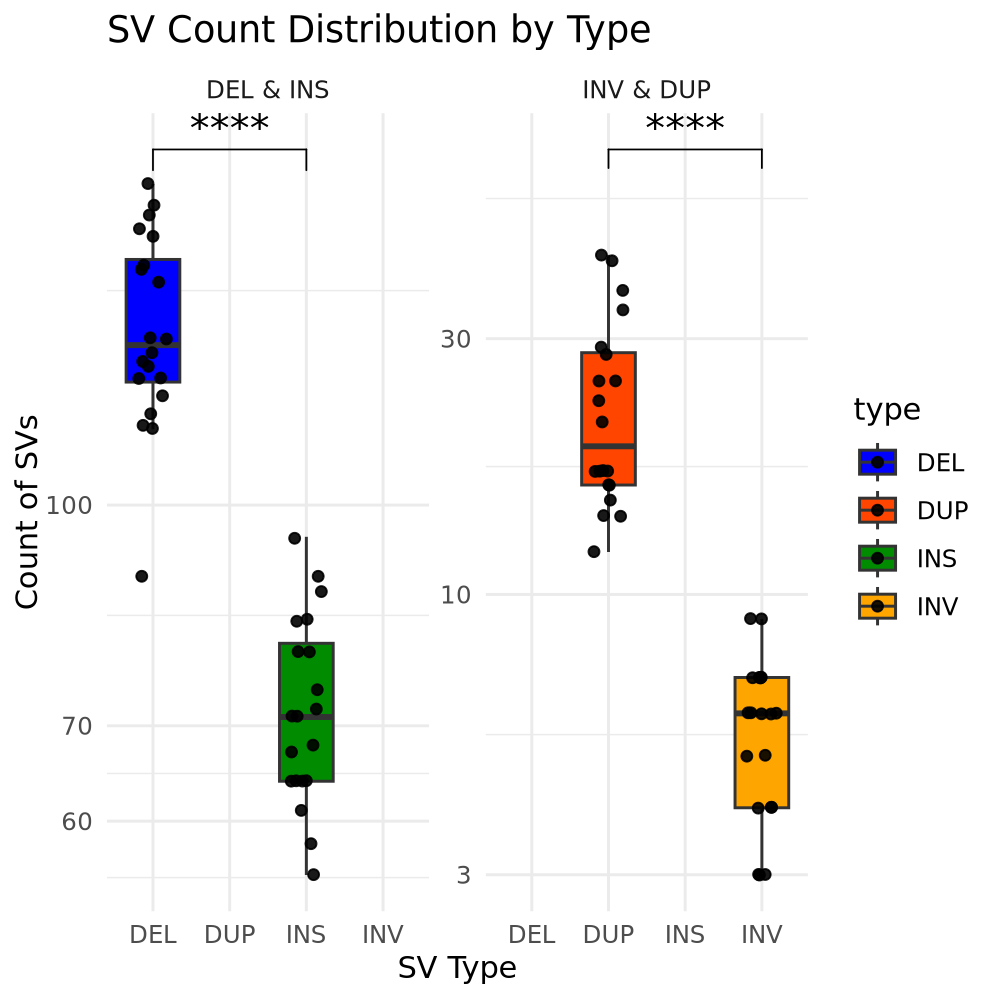

In [35]:
library(ggplot2)
library(ggpubr)

# Define colors for SV types
colors <- c("DEL" = "blue", "DUP" = "orangered", "INV" = "orange", "INS" = "green4")

# Define only the required pairwise comparisons
comparisons <- list(
  c("DEL", "INS"),
  c("INV", "DUP")
)

# Grouping for facet separation
sv_counts_complete$scale_group <- ifelse(sv_counts_complete$type %in% c("DEL", "INS"), "DEL & INS", "INV & DUP")

# Create the plot
ggplot(sv_counts_complete, aes(x = type, y = count, fill = type)) +
  geom_boxplot(outlier.shape = NA, width = 0.7) +  # Boxplot for distributions
  geom_jitter(width = 0.2, alpha = 0.9, size = 1.5) +  # Jitter points for low-count SVs
  stat_compare_means(comparisons = comparisons, method = "t.test", label = "p.signif", size = 5) +  # Wilcoxon test
  labs(x = "SV Type", y = "Count of SVs", title = "SV Count Distribution by Type") +
  scale_fill_manual(values = colors) +
  theme_minimal() +
  facet_wrap(~scale_group, scales = "free_y") +  # Separate DEL/INS and INV/DUP for clarity
  scale_y_log10()  # Log scale to make low-count SVs (DUP) visible



In [29]:
head(sv_counts_complete)

filename,type,count,scale_group
<chr>,<chr>,<int>,<chr>
2436A,DEL,123,DEL & INS
2436A,DUP,28,INV & DUP
2436A,INS,67,DEL & INS
2436A,INV,7,INV & DUP
3188,DEL,156,DEL & INS
3188,DUP,42,INV & DUP


In [33]:
plot_sv_histogram <- function(sv_type, color) {
  ggplot(data %>% filter(type == sv_type), 
         aes(x = size, fill = type)) +
    geom_histogram(binwidth = 0.1, alpha = 0.6, position = "identity", color = "black") +  # Histogram with binwidth of 0.1
    scale_x_continuous(trans = "log10", 
                       breaks = c(1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000),  # Log scale breaks up to 10M
                       labels = function(x) {
                         # Handle custom labels based on magnitude
                         sapply(x, function(val) {
                           if (is.na(val)) {
                             return(NA)  # Return NA if the value is not numeric
                           } else if (val < 1000) {
                             return(paste0(val))  # No scaling for values < 1k
                           } else if (val >= 1000 && val < 10000) {
                             return(paste0(val / 1000, "k"))  # Values between 1k and 10k
                           } else if (val >= 10000 && val < 100000) {
                             return(paste0(val / 1000, "k"))  # Values between 10k and 100k
                           } else if (val >= 100000 && val < 1000000) {
                             return(paste0(val / 1000, "k"))  # Values between 100k and 1M
                           } else if (val >= 1000000 && val < 10000000) {
                             return(paste0(val / 1000000, "M"))  # Values between 1M and 10M
                           } else {
                             return(paste0(val / 1000000, "M"))  # For values >= 10M
                           }
                         })
                       }) +  # Custom labels for x-axis based on size
    scale_fill_manual(values = setNames(color, sv_type)) +
    labs(x = "SV Size", y = "Count") +
    theme_minimal(base_size = 8) +  # Clean theme with larger text
    theme(axis.text.x = element_text(angle = 0, hjust = 1),  # Angle x-axis labels for better readability
          axis.title.x = element_text(face = "bold"),  # Bold x-axis label
          axis.title.y = element_text(face = "bold"),  # Bold y-axis label
          axis.text = element_text(size = 8),  # Increase text size
          panel.grid.major = element_blank(),  # Remove major grid lines for a cleaner look
          panel.grid.minor = element_blank(),  # Remove minor grid lines
          plot.title = element_text(face = "bold", hjust = 0.5))  # Centered title
}
#options(repr.plot.width = 5, repr.plot.height = 2, repr.plot.res = 200)

#pdf("/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/size_histogram_v2.pdf", height = 6, width = 14)

# Call your plotting function for each SV type
plot_sv_histogram("DEL", "blue")  # Deletions
plot_sv_histogram("DUP", "tomato")   # Duplications
plot_sv_histogram("INV", "orange") # Inversions
plot_sv_histogram("INS", "green4") # Insertions

#dev.off()  # Close the PDF device


pdf 
  2